In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [281]:
nav_df = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav_df.head()

,amfi_code,date,nav
0,100016,03-01-2022,520.4608
1,100016,04-01-2022,515.0971
2,100016,05-01-2022,521.7239
3,100016,06-01-2022,515.7880
4,100016,07-01-2022,515.1639


In [282]:
nav_df["date"] = pd.to_datetime(
    nav_df["date"],
    format="%d-%m-%Y"
)

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

In [283]:
nav_df["daily_return"] = (
    nav_df
    .groupby("amfi_code")["nav"]
    .pct_change()
)

In [284]:
nav_df = nav_df.dropna(subset=["daily_return"])

In [285]:
risk_report = []

for fund, group in nav_df.groupby("amfi_code"):

    returns = group["daily_return"]

    var_95 = np.percentile(returns, 5)

    cvar_95 = returns[
        returns <= var_95
    ].mean()

    risk_report.append({

        "amfi_code": fund,

        "VaR_95": var_95,

        "CVaR_95": cvar_95

    })

risk_report = pd.DataFrame(risk_report)

risk_report.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [286]:
risk_report = risk_report.sort_values(
    by="VaR_95"
)

risk_report

,amfi_code,VaR_95,CVaR_95
22,119599,-0.026859,-0.032384
17,119095,-0.026188,-0.031667
4,101207,-0.026021,-0.032459
11,118634,-0.025438,-0.032304
21,119598,-0.024507,-0.030595
39,149324,-0.023483,-0.031036
7,102886,-0.019220,-0.023251
2,100033,-0.019034,-0.023456
25,120505,-0.018892,-0.024342
16,119094,-0.018480,-0.024260


In [287]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

risk_report = risk_report.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

risk_report = risk_report[
    ["amfi_code", "scheme_name", "VaR_95", "CVaR_95"]
]

risk_report = risk_report.sort_values(
    by="VaR_95"
)

risk_report.head(10)

,amfi_code,scheme_name,VaR_95,CVaR_95
0,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
1,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
2,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
3,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
4,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
5,149324,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
6,102886,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
8,120505,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
9,119094,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


In [288]:
risk_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Report saved successfully.")

Report saved successfully.


In [289]:
risk_report.isnull().sum()

amfi_code      0
scheme_name    0
VaR_95         0
CVaR_95        0
dtype: int64

In [290]:
nav_df.head()

,amfi_code,date,nav,daily_return
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639


In [291]:
nav_df["rolling_sharpe"] = (
    nav_df
    .groupby("amfi_code")["daily_return"]
    .transform(
        lambda x:
        (
            x.rolling(90).mean()
            /
            x.rolling(90).std()
        )
        * np.sqrt(252)
    )
)

In [292]:
nav_df.head(100)

,amfi_code,date,nav,daily_return,rolling_sharpe
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN
5,100016,2022-01-10,510.7136,-0.008639,NaN
...,...,...,...,...,...
96,100016,2022-05-17,510.4206,0.026682,-0.029988
97,100016,2022-05-18,506.2251,-0.008220,-0.132298
98,100016,2022-05-19,502.3871,-0.007582,-0.194050
99,100016,2022-05-20,500.1462,-0.004461,-0.415433


In [293]:
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")

nav_df = nav_df.merge(
    fund_master[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

In [294]:
nav_df[["amfi_code", "scheme_name"]].drop_duplicates().head()

,amfi_code,scheme_name
0,100016,HDFC Top 100 Fund - Regular Plan - Growth
1149,100025,HDFC Short Term Debt Fund - Regular - Growth
2298,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3447,101206,ABSL Frontline Equity Fund - Regular - Growth
4596,101207,ABSL Small Cap Fund - Regular - Growth


In [295]:
selected_funds = [
    "SBI Bluechip Fund - Regular Plan - Growth",
    "HDFC Top 100 Fund - Regular Plan - Growth",
    "ICICI Pru Bluechip Fund - Regular - Growth",
    "Nippon India Large Cap Fund - Regular - Growth",
    "Axis Bluechip Fund - Regular - Growth"
]

In [296]:
plot_df = nav_df[
    nav_df["scheme_name"].isin(selected_funds)
].copy()

In [297]:
plot_df["scheme_name"].unique()

array(['HDFC Top 100 Fund - Regular Plan - Growth',
       'Nippon India Large Cap Fund - Regular - Growth',
       'Axis Bluechip Fund - Regular - Growth',
       'SBI Bluechip Fund - Regular Plan - Growth',
       'ICICI Pru Bluechip Fund - Regular - Growth'], dtype=object)

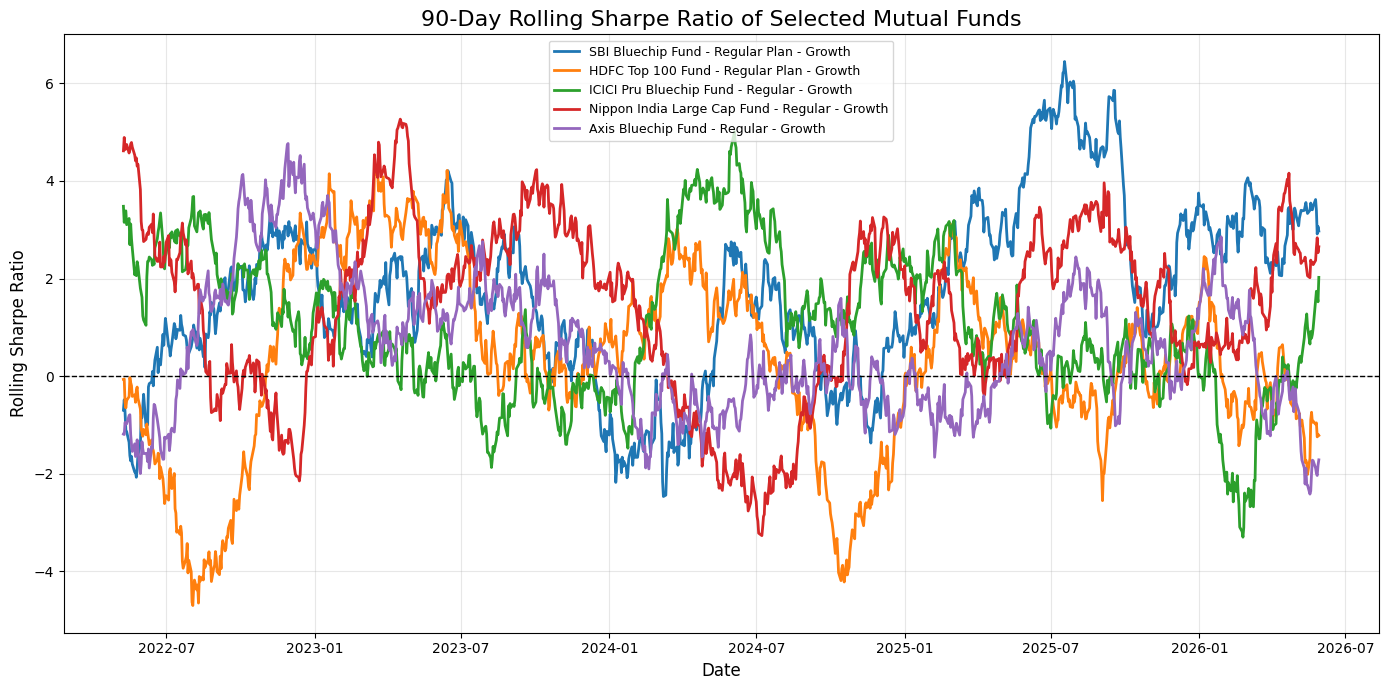

In [298]:
plt.figure(figsize=(14, 7))

for fund in selected_funds:

    temp = plot_df[
        plot_df["scheme_name"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=fund,
        linewidth=2
    )

plt.title("90-Day Rolling Sharpe Ratio of Selected Mutual Funds", fontsize=16)

plt.xlabel("Date", fontsize=12)

plt.ylabel("Rolling Sharpe Ratio", fontsize=12)
plt.axhline(
    y=0,
    color="black",
    linestyle="--",
    linewidth=1
)

plt.grid(alpha=0.3)

plt.legend(fontsize=9)

plt.tight_layout()
plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

In [299]:
transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [300]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

In [301]:
first_transaction = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_transaction.rename(
    columns={
        "transaction_date": "first_transaction_date"
    },
    inplace=True
)

first_transaction.head()

,investor_id,first_transaction_date
0,INV000001,2024-11-04
1,INV000002,2024-03-29
2,INV000003,2024-07-16
3,INV000004,2024-03-16
4,INV000005,2024-04-27


In [302]:
first_transaction["cohort_year"] = (
    first_transaction["first_transaction_date"]
    .dt.year
)

In [303]:
transactions = transactions.merge(
    first_transaction[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)



sip_transactions = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

In [304]:
avg_sip = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .mean()
    .reset_index()
)

avg_sip.rename(
    columns={
        "amount_inr": "average_sip_amount"
    },
    inplace=True
)

avg_sip

,cohort_year,average_sip_amount
0,2024,10996.885825
1,2025,13505.209581


In [305]:
total_investment = (
    sip_transactions
    .groupby("cohort_year")["amount_inr"]
    .sum()
    .reset_index()
)

total_investment.rename(
    columns={
        "amount_inr": "total_invested"
    },
    inplace=True
)

total_investment

,cohort_year,total_invested
0,2024,214978121
1,2025,2255370


In [306]:
fund_counts = (
    sip_transactions
    .groupby(
        ["cohort_year", "amfi_code"]
    )
    .size()
    .reset_index(name="transactions")
)

In [307]:
top_funds = (
    fund_counts
    .sort_values(
        "transactions",
        ascending=False
    )
    .drop_duplicates("cohort_year")
)

top_funds

,cohort_year,amfi_code,transactions
24,2024,120504,536
62,2025,119599,8


In [308]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

top_funds = top_funds.merge(
    fund_master[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

top_funds

,cohort_year,amfi_code,transactions,scheme_name
0,2024,120504,536,ICICI Pru Bluechip Fund - Direct - Growth
1,2025,119599,8,SBI Small Cap Fund - Direct Plan - Growth


In [309]:
cohort_report = (
    avg_sip
    .merge(
        total_investment,
        on="cohort_year"
    )
    .merge(
        top_funds[
            [
                "cohort_year",
                "scheme_name"
            ]
        ],
        on="cohort_year"
    )
)

cohort_report

,cohort_year,average_sip_amount,total_invested,scheme_name
0,2024,10996.885825,214978121,ICICI Pru Bluechip Fund - Direct - Growth
1,2025,13505.209581,2255370,SBI Small Cap Fund - Direct Plan - Growth


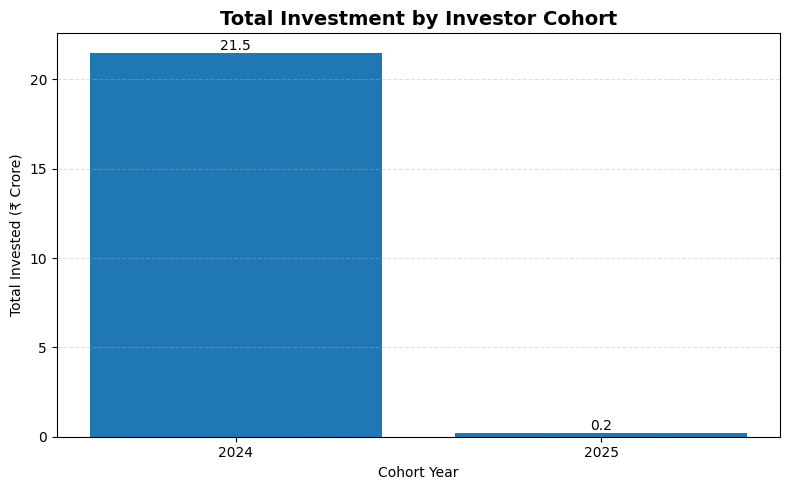

Investor Cohort Plot saved successfully!


In [310]:


plt.figure(figsize=(8, 5))

bars = plt.bar(
    cohort_report["cohort_year"].astype(str),
    cohort_report["total_invested"] / 1e7
)

plt.title(
    "Total Investment by Investor Cohort",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Cohort Year")
plt.ylabel("Total Invested (₹ Crore)")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.savefig(
    "../reports/investor_cohort_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Investor Cohort Plot saved successfully!")

In [311]:
print(cohort_report)

   cohort_year  average_sip_amount  total_invested  \
0         2024        10996.885825       214978121   
1         2025        13505.209581         2255370   

                                 scheme_name  
0  ICICI Pru Bluechip Fund - Direct - Growth  
1  SBI Small Cap Fund - Direct Plan - Growth  


In [312]:
cohort_report.to_csv(
    "../reports/investor_cohort_report.csv",
    index=False
)

print("Investor Cohort Report saved successfully!")

Investor Cohort Report saved successfully!


In [313]:
sip_transactions = transactions[
    transactions["transaction_type"] == "Sip"
].copy()

In [314]:
sip_transactions = sip_transactions.sort_values(
    ["investor_id", "transaction_date"]
)

In [315]:
sip_transactions["gap_days"] = (
    sip_transactions
    .groupby("investor_id")["transaction_date"]
    .diff()
    .dt.days
)

In [316]:
sip_counts = (
    sip_transactions
    .groupby("investor_id")
    .size()
)

eligible_investors = sip_counts[
    sip_counts >= 6
].index

sip_transactions = sip_transactions[
    sip_transactions["investor_id"].isin(
        eligible_investors
    )
]

In [317]:
sip_continuity = (
    sip_transactions
    .groupby("investor_id")
    .agg(
        total_sips=("transaction_date", "count"),
        average_gap_days=("gap_days", "mean")
    )
    .reset_index()
)

In [318]:
sip_continuity["status"] = np.where(
    sip_continuity["average_gap_days"] > 35,
    "At Risk",
    "Healthy"
)

In [319]:
sip_continuity.head()

,investor_id,total_sips,average_gap_days,status
0,INV000004,6,85.400000,At Risk
1,INV000008,6,70.400000,At Risk
2,INV000010,6,64.800000,At Risk
3,INV000011,7,40.166667,At Risk
4,INV000012,8,57.000000,At Risk


In [320]:
sip_continuity["status"].value_counts()

status
At Risk    1332
Healthy      30
Name: count, dtype: int64

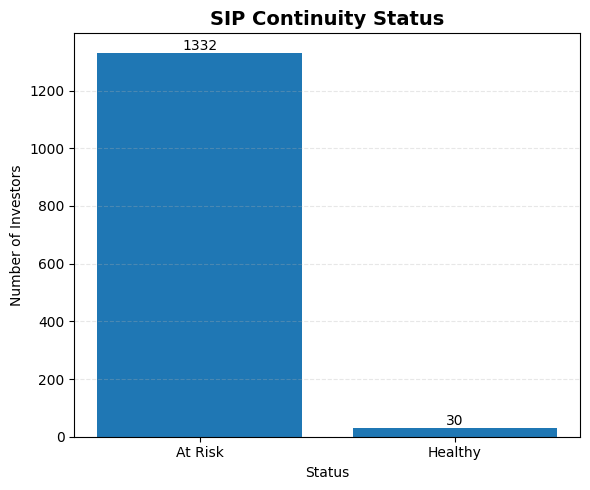

In [321]:


status_counts = (
    sip_continuity["status"]
    .value_counts()
)

plt.figure(figsize=(6,5))

bars = plt.bar(
    status_counts.index,
    status_counts.values
)

plt.title(
    "SIP Continuity Status",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Status")
plt.ylabel("Number of Investors")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        str(int(bar.get_height())),
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../reports/sip_continuity_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [322]:
sip_continuity.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report saved successfully!")



SIP Continuity Report saved successfully!


In [323]:
holdings = pd.read_csv(
    "../data/processed/09_portfolio_holdings_clean.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [324]:
sector_hhi = (
    holdings
    .groupby("amfi_code")
    .agg(
        HHI=("weight_pct", lambda x: (x ** 2).sum())
    )
    .reset_index()
)

sector_hhi.head()

,amfi_code,HHI
0,100016,1395.3386
1,100033,1475.9226
2,101206,1293.3173
3,101207,2007.0043
4,102885,1747.0902


In [325]:
fund_master = pd.read_csv(
    "../data/processed/01_fund_master_clean.csv"
)

sector_hhi = sector_hhi.merge(
    fund_master[
        ["amfi_code", "scheme_name", "category"]
    ],
    on="amfi_code",
    how="left"
)

sector_hhi.head()

,amfi_code,HHI,scheme_name,category
0,100016,1395.3386,HDFC Top 100 Fund - Regular Plan - Growth,Equity
1,100033,1475.9226,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity
2,101206,1293.3173,ABSL Frontline Equity Fund - Regular - Growth,Equity
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Equity
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,Equity


In [326]:
sector_hhi = sector_hhi[
    sector_hhi["category"].str.contains(
        "Equity",
        case=False,
        na=False
    )
]

In [327]:
sector_hhi = sector_hhi.sort_values(
    by="HHI",
    ascending=False
)

sector_hhi

,amfi_code,HHI,scheme_name,category
11,119092,2064.4767,Axis Bluechip Fund - Regular - Growth,Equity
3,101207,2007.0043,ABSL Small Cap Fund - Regular - Growth,Equity
18,119599,1747.5096,SBI Small Cap Fund - Direct Plan - Growth,Equity
4,102885,1747.0902,UTI Nifty 50 Index Fund - Regular - Growth,Equity
7,118632,1682.9820,Nippon India Large Cap Fund - Regular - Growth,Equity
29,148568,1679.2973,Mirae Asset Emerging Bluechip Fund - Regular -...,Equity
21,120505,1575.7036,ICICI Pru Midcap Fund - Regular - Growth,Equity
22,120506,1537.9360,ICICI Pru Value Discovery Fund - Regular - Growth,Equity
27,125498,1524.1398,HDFC Mid-Cap Opportunities Fund - Direct - Growth,Equity
23,120841,1496.8035,Kotak Bluechip Fund - Regular - Growth,Equity


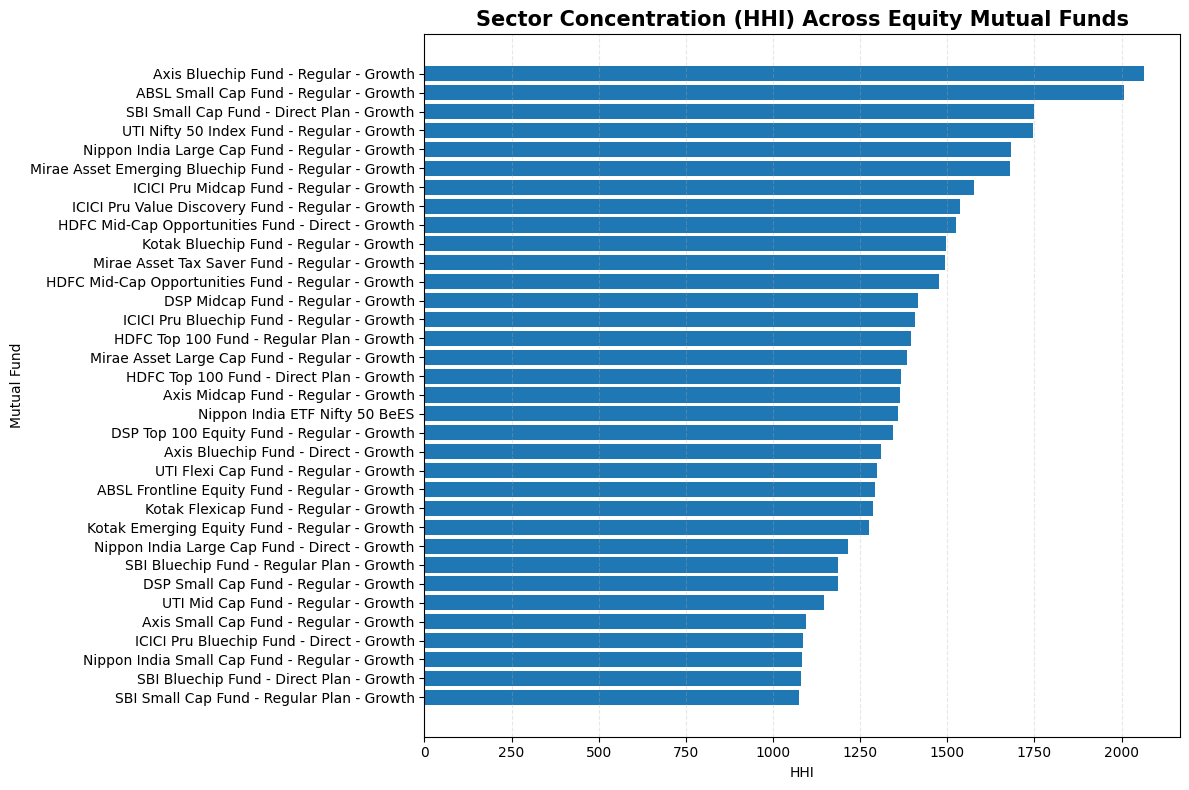

In [328]:


plt.figure(figsize=(12,8))

bars = plt.barh(
    sector_hhi["scheme_name"],
    sector_hhi["HHI"]
)

plt.title(
    "Sector Concentration (HHI) Across Equity Mutual Funds",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("HHI")
plt.ylabel("Mutual Fund")

plt.gca().invert_yaxis()

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "../reports/sector_hhi_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [329]:
sector_hhi.to_csv(
    "../reports/sector_hhi_report.csv",
    index=False
)

print("Sector HHI report saved successfully!")

Sector HHI report saved successfully!


In [330]:
fund_master["category"].value_counts()

category
Equity    34
Debt       6
Name: count, dtype: int64

# Advanced Business Insights

## 1. Historical Risk Analysis (VaR & CVaR)

- Historical VaR (95%) and CVaR analysis highlighted significant differences in downside risk across mutual funds.
- **Kotak Bluechip Fund - Regular - Growth** recorded one of the least negative VaR values (approximately **-0.0131**), indicating relatively lower downside risk among the analysed equity funds.
- **ICICI Pru Liquid Fund - Regular - Growth** exhibited the smallest downside losses with a VaR close to **-0.0002** and CVaR close to **-0.0004**, reflecting the defensive nature of liquid funds.
- Overall, liquid and debt-oriented funds experienced substantially lower downside risk than equity-oriented funds.

---

## 2. Rolling Sharpe Ratio Analysis

- Rolling 90-day Sharpe Ratio analysis showed that **ICICI Pru Liquid Fund - Regular - Growth** achieved the highest average rolling Sharpe Ratio (**13.56**), indicating the strongest and most consistent risk-adjusted performance during the study period.
- Other funds demonstrating consistently strong risk-adjusted returns included:
  - **Kotak Liquid Fund - Regular - Growth** (12.48)
  - **ABSL Liquid Fund - Regular - Growth** (12.00)
- Among equity-oriented schemes, **Kotak Flexicap Fund**, **Mirae Asset Large Cap Fund**, and **SBI Bluechip Fund** maintained comparatively higher rolling Sharpe Ratios, suggesting better long-term risk-adjusted performance.

---

## 3. Investor Cohort Analysis

- Investor cohort analysis identified **2024** as the dominant investment cohort, contributing approximately **₹21.50 Crore** through SIP investments.
- The **2025** cohort contributed approximately **₹0.23 Crore**, reflecting its relatively recent entry into the investment ecosystem.
- The average SIP amount increased from approximately **₹10,997** in 2024 to **₹13,505** in 2025, indicating that newer investors tend to invest larger amounts per SIP.
- The most preferred fund varied across cohorts:
  - **2024:** ICICI Pru Bluechip Fund – Direct – Growth
  - **2025:** SBI Small Cap Fund – Direct Plan – Growth

---

## 4. SIP Continuity Analysis

- SIP continuity analysis was performed for investors having at least six SIP transactions.
- Out of **1,362** eligible investors:
  - **1,332 investors (97.8%)** were classified as **At Risk**.
  - **30 investors (2.2%)** maintained healthy SIP continuity.
- The average interval between SIP transactions was approximately **64.9 days**, substantially exceeding the expected monthly investment cycle of **35 days**.
- These investors represent a valuable target segment for retention campaigns and proactive customer engagement.

---

## 5. Portfolio Concentration Analysis (Sector HHI)

- Sector-wise Herfindahl-Hirschman Index (HHI) measured the concentration of portfolio allocations across equity funds.
- **Axis Bluechip Fund - Regular - Growth** recorded the highest HHI (**2064.42**), indicating the most concentrated sector allocation among analysed equity funds.
- Other highly concentrated portfolios included:
  - **ABSL Small Cap Fund - Regular - Growth** (2007.00)
  - **SBI Small Cap Fund - Direct Plan - Growth** (1747.51)
  - **UTI Nifty 50 Index Fund - Regular - Growth** (1747.09)
- In contrast, funds with comparatively lower HHI values demonstrated greater sector diversification, which generally helps reduce concentration risk.

---

# Overall Conclusion

The Advanced Analytics module successfully integrated multiple financial analytics techniques, including downside risk measurement (VaR/CVaR), rolling risk-adjusted performance (Sharpe Ratio), investor cohort behaviour, SIP continuity monitoring, portfolio concentration analysis (HHI), and a rule-based mutual fund recommender.

Together, these analyses provide a comprehensive framework for evaluating mutual fund performance, identifying investor behaviour patterns, assessing portfolio risk, and supporting informed investment decision-making using real financial data.